# Síntese e Ponte para o Teorema Central do Limite
## Os dois casos lado a lado — mesma lei, velocidades opostas

**Trabalho de Probabilidade — Aplicações da Lei dos Grandes Números (LGN)**

Os notebooks 1 e 2 estudaram a LGN em dois fenômenos opostos:

- **Mega-Sena** (discreto): alvo conhecido, variância moderada, convergência limpa.
- **Retornos** (contínuo): alvo estimado, variância enorme, convergência lenta e ruidosa.

Este notebook fecha o trabalho com três objetivos:

1. **Comparar diretamente** as duas convergências num mesmo eixo, tornando visível que
   ambas decaem como $1/\sqrt{n}$ — só que deslocadas pelo coeficiente de variação.
2. **Unificar** os dois casos sob uma única quantidade: o erro relativo
   $\text{CV}/\sqrt{n}$.
3. **Formalizar a ponte LGN $\to$ TCL**: a LGN diz *para onde* a média vai; o Teorema
   Central do Limite diz *com que forma e a que velocidade* — e isso vale mesmo quando
   os dados individuais não são normais (loteria discreta, retornos de cauda pesada).


---
## 1. Carregando e preparando os dois conjuntos

Reproduzimos o tratamento dos notebooks anteriores para ter, em memória, as duas
"populações":

- `dezenas` — as 13.668 dezenas da Mega-Sena (na ordem dos concursos);
- `R` — os retornos diários simples da ação.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# ---- Caso discreto: Mega-Sena ----
cols_dezenas = ["1ª Dezena", "2ª Dezena", "3ª Dezena",
                "4ª Dezena", "5ª Dezena", "6ª Dezena"]
mega = pd.read_csv("../data/sorteios.csv", encoding="utf-8", dtype=str)
mega = mega[["Concurso", "Data Sorteio"] + cols_dezenas].copy()
mega["Data Sorteio"] = pd.to_datetime(mega["Data Sorteio"], format="%d/%m/%Y")
mega["Concurso"] = mega["Concurso"].astype(int)
for c in cols_dezenas:
    mega[c] = mega[c].astype(int)
mega = mega.sort_values(["Data Sorteio", "Concurso"]).reset_index(drop=True)
dezenas = mega[cols_dezenas].to_numpy().ravel()

# ---- Caso contínuo: retornos ----
ret = pd.read_csv("../data/retornos.csv", parse_dates=["Data"]).sort_values("Data")
R = ret["retorno_simples"].to_numpy()

print(f"Mega-Sena : {dezenas.size} dezenas")
print(f"Retornos  : {R.size} dias")

Mega-Sena : 13668 dezenas
Retornos  : 2490 dias


In [2]:
# Parâmetros (alvos e dispersão) de cada caso.
# Loteria: alvo TEÓRICO conhecido; retornos: alvo ESTIMADO da própria série.
mu_lot, sigma_lot = 30.5, np.sqrt((60**2 - 1) / 12)   # teóricos
mu_ret, sigma_ret = R.mean(), R.std(ddof=1)           # estimados

cv_lot = sigma_lot / abs(mu_lot)
cv_ret = sigma_ret / abs(mu_ret)

resumo = pd.DataFrame({
    "Mega-Sena (discreto)": [mu_lot, sigma_lot, cv_lot, "conhecido a priori"],
    "Retornos (contínuo)":  [mu_ret, sigma_ret, cv_ret, "estimado dos dados"],
}, index=["média μ", "desvio σ", "coef. variação σ/|μ|", "alvo"])
resumo

,Mega-Sena (discreto),Retornos (contínuo)
média μ,30.5,0.001445
desvio σ,17.318102,0.025872
coef. variação σ/|μ|,0.567807,17.908158
alvo,conhecido a priori,estimado dos dados


---
## 2. As duas convergências no mesmo eixo

Para comparar fenômenos de escalas tão diferentes (dezenas $\sim 30$, retornos
$\sim 0{,}001$), olhamos o **erro relativo** da média acumulada:

$$e_n = \frac{\big|\bar{X}_n - \mu\big|}{|\mu|}.$$

A teoria prevê que $e_n$ flutue em torno de $\text{CV}/\sqrt{n}$. Em escala log-log,
isso vira uma reta de inclinação $-\tfrac{1}{2}$ — a **mesma** para os dois casos —,
apenas deslocada verticalmente pelo CV.


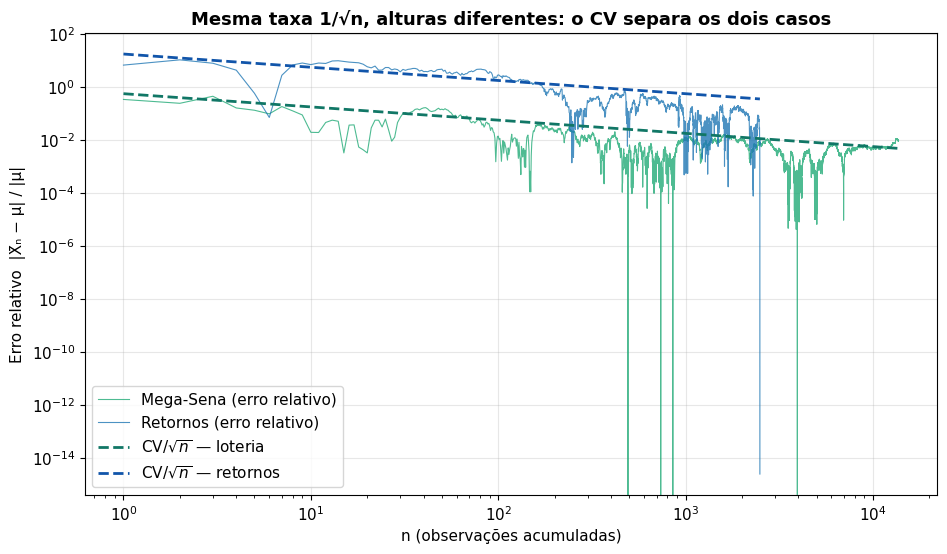

In [3]:
def media_acumulada(x):
    n = np.arange(1, len(x) + 1)
    return n, np.cumsum(x) / n

n_lot, mac_lot = media_acumulada(dezenas)
n_ret, mac_ret = media_acumulada(R)

err_lot = np.abs(mac_lot - mu_lot) / abs(mu_lot)
err_ret = np.abs(mac_ret - mu_ret) / abs(mu_ret)

fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(n_lot, err_lot, lw=0.8, color="#2a7", alpha=0.8, label="Mega-Sena (erro relativo)")
ax.loglog(n_ret, err_ret, lw=0.8, color="#1f77b4", alpha=0.8, label="Retornos (erro relativo)")
# Linhas de referência CV/sqrt(n)
ax.loglog(n_lot, cv_lot / np.sqrt(n_lot), "--", color="#176", lw=2,
          label=r"$\mathrm{CV}/\sqrt{n}$ — loteria")
ax.loglog(n_ret, cv_ret / np.sqrt(n_ret), "--", color="#15a", lw=2,
          label=r"$\mathrm{CV}/\sqrt{n}$ — retornos")
ax.set_xlabel("n (observações acumuladas)")
ax.set_ylabel("Erro relativo  |X̄ₙ − μ| / |μ|")
ax.set_title("Mesma taxa 1/√n, alturas diferentes: o CV separa os dois casos")
ax.legend()
plt.show()

**Lendo o gráfico.** As duas nuvens de erro descem com a **mesma inclinação**
($-\tfrac12$ em log-log) — a assinatura universal do $1/\sqrt{n}$. O que as separa é a
**altura**: a curva dos retornos vive cerca de $30\times$ acima da loteria, exatamente
a razão entre os coeficientes de variação. Em uma figura: *a LGN é a mesma; o CV decide
quão alto você começa e, portanto, quanto tempo leva para descer.*


---
## 3. Quanto custa cada dígito de precisão

Invertendo $\text{CV}/\sqrt{n} = e$, o número de observações para um erro relativo
$e$ é $n = (\text{CV}/e)^2$. A dependência quadrática em $1/e$ é dura: **ganhar um
dígito (10×) de precisão custa 100× mais dados.**


In [4]:
alvos = [0.10, 0.05, 0.01]   # erros relativos desejados
tabela = pd.DataFrame({
    "erro relativo": [f"{e:.0%}" for e in alvos],
    "Mega-Sena (n)": [f"{(cv_lot/e)**2:,.0f}" for e in alvos],
    "Retornos (n)":  [f"{(cv_ret/e)**2:,.0f}" for e in alvos],
    "Retornos (~anos pregão)": [f"{(cv_ret/e)**2/252:,.0f}" for e in alvos],
})
tabela

,erro relativo,Mega-Sena (n),Retornos (n),Retornos (~anos pregão)
0,10%,32,"32,070",127
1,5%,129,"128,281",509
2,1%,"3,224","3,207,021","12,726"


**Lendo a tabela.** Para a loteria, algumas dezenas de sorteios já bastam para
$10\%$. Para os retornos, o mesmo $10\%$ exige dezenas de milhares de pregões — mais de
um século — e exigir $1\%$ é, na prática, inviável. É a tradução numérica de "a LGN
vale, mas não promete pressa".


---
## 4. Da LGN para o Teorema Central do Limite (TCL)

A LGN responde **para onde** a média vai ($\bar{X}_n \to \mu$). O **TCL** responde
**como** ela se distribui em torno desse alvo. Para $X_i$ i.i.d. com média $\mu$ e
variância $\sigma^2$,

$$Z_n = \frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}}
\;\xrightarrow{\;d\;}\; \mathcal{N}(0, 1)
\qquad (n \to \infty).$$

Equivalentemente, $\bar{X}_n \approx \mathcal{N}\!\big(\mu,\ \sigma^2/n\big)$. Dois
pontos notáveis:

- **Universalidade (de novo):** o limite é normal *qualquer que seja* a distribuição de
  origem — discreta uniforme (loteria) ou contínua de cauda pesada (retornos).
- **Relação com a LGN:** o TCL é um *refinamento*. A LGN diz que a dispersão de
  $\bar{X}_n$ some; o TCL diz que, **reescalada** por $\sqrt{n}$, essa dispersão tem
  forma de sino. Verificamos isso padronizando médias amostrais de tamanho crescente.


In [5]:
def medias_padronizadas(pop, n, mu, sigma, B=5000, rng=None):
    # Sorteia B amostras de tamanho n e devolve as médias padronizadas Z.
    rng = rng or np.random.default_rng(0)
    amostras = rng.choice(pop, size=(B, n), replace=True)
    medias = amostras.mean(axis=1)
    return (medias - mu) / (sigma / np.sqrt(n))

# Densidade normal-padrão para sobrepor.
xx = np.linspace(-4, 4, 200)
pdf_normal = np.exp(-xx**2 / 2) / np.sqrt(2 * np.pi)
rng = np.random.default_rng(2024)

### 4.1 Caso discreto — médias de dezenas

A distribuição de uma dezena é **uniforme** em $\{1,\dots,60\}$ (nada de sino). Mesmo
assim, a média de poucas dezenas já fica aproximadamente normal.


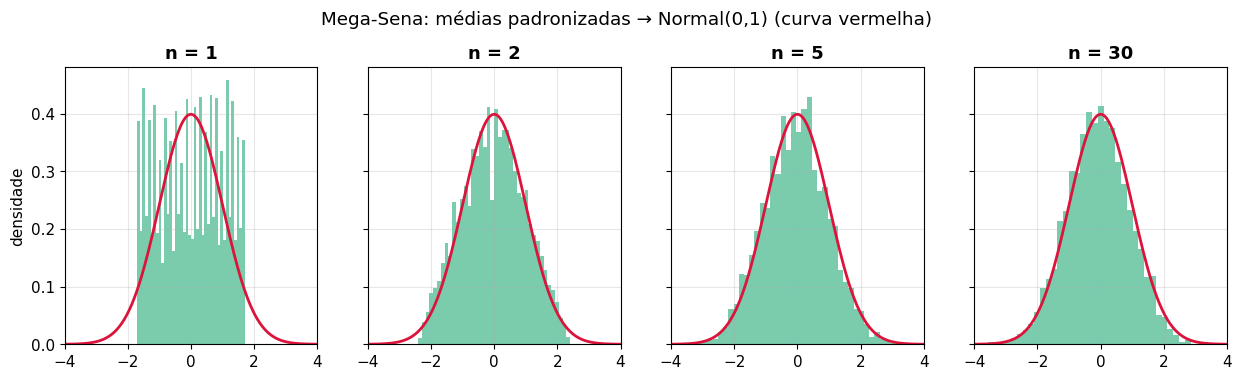

In [6]:
ns = [1, 2, 5, 30]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, n in zip(axes, ns):
    Z = medias_padronizadas(dezenas, n, mu_lot, sigma_lot, rng=rng)
    ax.hist(Z, bins=40, density=True, color="#2a7", alpha=0.6)
    ax.plot(xx, pdf_normal, "crimson", lw=2)
    ax.set_title(f"n = {n}")
    ax.set_xlim(-4, 4)
axes[0].set_ylabel("densidade")
fig.suptitle("Mega-Sena: médias padronizadas → Normal(0,1) (curva vermelha)", y=1.04)
plt.show()

**Lendo o gráfico.** Em $n=1$ vemos a "cara" uniforme (caixa achatada). Já em
$n=2$ surge o triângulo, e por volta de $n=5$–$30$ o histograma praticamente coincide
com a normal-padrão. Convergência **rápida** ao TCL — coerente com a baixa variância
e a simetria da uniforme.


### 4.2 Caso contínuo — médias de retornos

Os retornos têm **caudas pesadas** e dias extremos (vimos quedas de ~30%). Isso retarda
o TCL: para $n$ pequeno o histograma ainda tem caudas mais grossas que a normal.


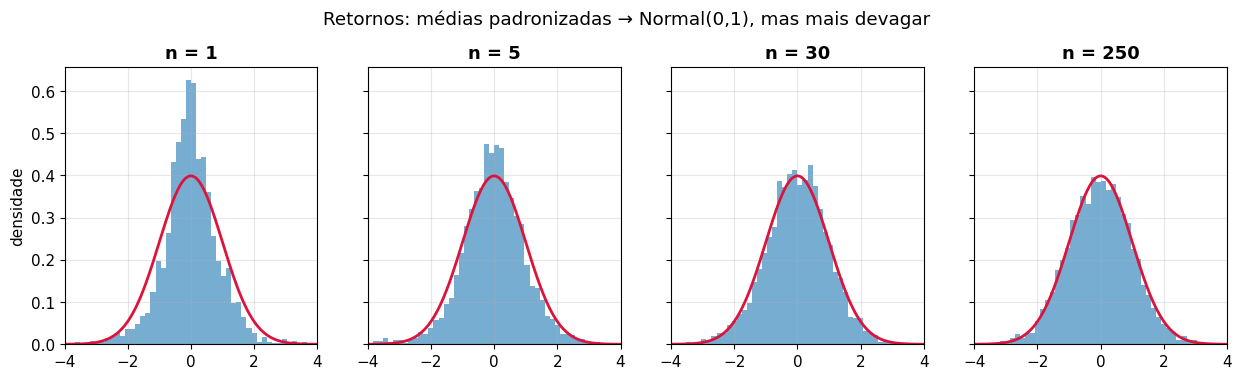

In [7]:
ns = [1, 5, 30, 250]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, n in zip(axes, ns):
    Z = medias_padronizadas(R, n, mu_ret, sigma_ret, rng=rng)
    ax.hist(Z, bins=50, density=True, color="#1f77b4", alpha=0.6, range=(-4, 4))
    ax.plot(xx, pdf_normal, "crimson", lw=2)
    ax.set_title(f"n = {n}")
    ax.set_xlim(-4, 4)
axes[0].set_ylabel("densidade")
fig.suptitle("Retornos: médias padronizadas → Normal(0,1), mas mais devagar", y=1.04)
plt.show()

**Lendo o gráfico.** Em $n=1$ a distribuição é pontiaguda no centro e com caudas
grossas (longe da normal). Conforme $n$ cresce, o sino se forma e em $n=250$ a
aproximação normal já é boa. A **mesma** mensagem da LGN reaparece no TCL: a convergência
existe nos dois casos (universalidade), mas é **mais lenta** onde a variância/caudas são
maiores.


---
## 5. Síntese final

Reunindo os três notebooks:

| Pergunta | Resposta | Onde aparece |
|---|---|---|
| A média amostral converge para a esperança? | **Sim, sempre** (variância finita) | LGN — notebooks 1, 2 |
| A frequência relativa converge para a probabilidade? | Sim (LGN aplicada a indicadores) | Notebook 1 |
| Em que ritmo? | Erro $\sim \text{CV}/\sqrt{n}$ | Notebooks 2, 3 |
| Qual a forma da flutuação em torno do alvo? | Normal, reescalada por $\sqrt{n}$ | TCL — notebook 3 |
| Vale para qualquer distribuição? | Sim (universalidade), mas com velocidades diferentes | Todos |

**Conclusões do trabalho:**

1. **Universalidade.** A LGN e o TCL valem tanto para um sorteio discreto e simétrico
   quanto para retornos contínuos de cauda pesada. A *validade* não depende da forma da
   distribuição.
2. **Velocidade.** O que muda entre os fenômenos é o **ritmo**, governado pelo
   coeficiente de variação $\text{CV}=\sigma/|\mu|$. Com CV $\approx 0{,}57$ a loteria
   converge em dezenas de observações; com CV $\approx 18$ os retornos precisariam de
   ~1000× mais dados para a mesma precisão.
3. **Alvo conhecido vs. estimado.** Na loteria comparamos com valores deduzidos
   ($0{,}10$; $1/60$; $30{,}5$); nos retornos o alvo $\mu$ é estimado da própria série —
   uma situação mais realista e mais sujeita a incerteza.
4. **Honestidade sobre as hipóteses.** Sorteios são plausivelmente i.i.d.; retornos têm
   dependência temporal e volatilidade variável, então aplicamos a LGN/TCL como
   *aproximação informada*, amparada por versões mais fracas dessas leis.
5. **Da LGN ao TCL.** A LGN dá o destino; o TCL dá a forma e a taxa da chegada. Juntos,
   explicam por que médias são tão centrais em estatística — e por que algumas médias são
   muito mais difíceis de estimar que outras.
